In [1]:
conda install pandas matplotlib seaborn

Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /Users/aamukthakottapalli/miniconda3/envs/my_env

  added / updated specs:
    - matplotlib
    - pandas
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blas-1.0                   |         openblas          10 KB
    bottleneck-1.3.7           |  py312ha86b861_0         126 KB
    brotli-1.0.9               |       h80987f9_8          20 KB
    brotli-bin-1.0.9           |       h80987f9_8          18 KB
    contourpy-1.2.0            |  py312h48ca7d4_0         228 KB
    cycler-0.11.0              |     pyhd3eb1b0_0          12 KB
    fonttools-4.51.0           |  py312h80987f9_0         2.8 MB
    freetype-2.12.1            |       h1192e45_0         570 KB
    kiwisolver-1.4.4           |  py312h313beb8_0          54 KB
    lcms2-2.12                 |     

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading In and Checking Data
df = pd.read_csv('out.emapper.annotations_modified', header=4, sep='\t', usecols=['COG_category','score'])

print(df.head())

    score COG_category
0   262.0            Q
1  4688.0            S
2   106.0            -
3   280.0            H
4   310.0            C


In [4]:
# Filtering and Processing Data
df_non_null = df.dropna(subset=['COG_category','score']) # dropna() filters out null rows

# lambda - takes rows with multiple values and splits at comma, using 1st value
# extractall() - safegaurd to ensure only strings matching uppercase letter pattern are extracted
# apply() is used to apply a function along an axis of the data frame
cog_letters = df_non_null['COG_category'].apply(lambda x: x.split(',')[0]).str.extractall(r'([A-Z])')[0]
print(cog_letters)


# Counts occurrences of each letter
# value_counts() creates a Series - 1d array - where indices are the letters and the values are the counts
cog_counts = cog_letters.value_counts() 

# Converting to a data frame
# reset_index() converts Series into a dataframe - letters become a column    
cog_counts_df = cog_counts.reset_index()

# Rename the columns for clarity
cog_counts_df.columns = ['COG_category', 'count']

print(cog_counts_df)


      match
0     0        Q
1     0        S
3     0        H
4     0        C
5     0        D
              ..
5749  0        V
5750  0        H
5751  0        K
5752  0        D
      1        J
Name: 0, Length: 5120, dtype: object
   COG_category  count
0             S   1338
1             E    424
2             L    395
3             G    344
4             J    327
5             C    312
6             K    292
7             P    262
8             H    258
9             M    230
10            F    210
11            O    148
12            I    137
13            T    103
14            V     99
15            Q     85
16            D     74
17            U     62
18            N     16
19            B      2
20            Z      1
21            A      1


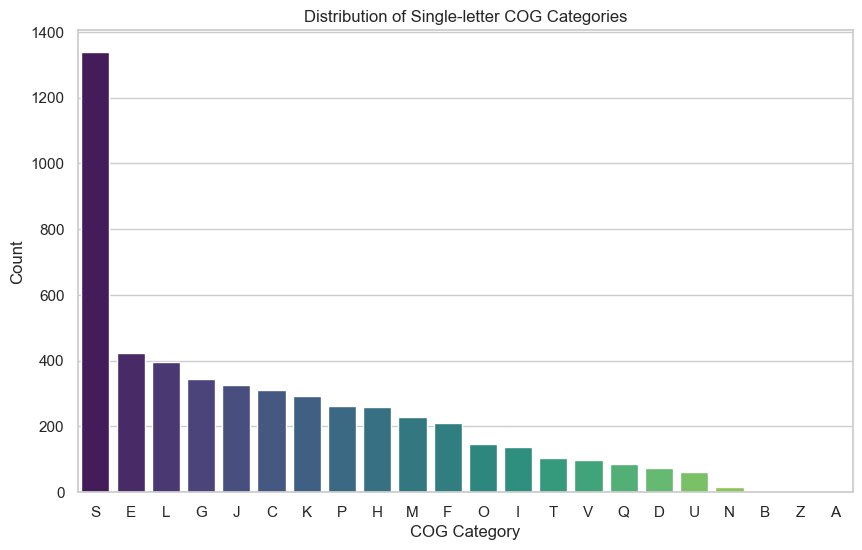

In [5]:
# Visualizing Data
sns.set(style="whitegrid")

# Creating a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='COG_category', y='count', data=cog_counts_df, palette='viridis')

plt.title('Distribution of Single-letter COG Categories')
plt.xlabel('COG Category')
plt.ylabel('Count')

# Save the plot to a file
plt.savefig('COG_category_distribution_single.png', dpi=300)

plt.show()

plt.close()